## Customer Fraud Detection – Binary Classification

#### Assignment No. 14

#### Data File: customer_analytics_dataset.csv

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder

from imblearn.over_sampling   import SMOTE

from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from xgboost                  import XGBClassifier
from sklearn.linear_model     import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11


In [3]:
df = pd.read_csv(r"G:\Jupyter Notebook\Practice Data Files\customer_analytics_dataset.csv")

In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   object 
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   object 
 3   country             5000 non-null   object 
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   object 
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   object 
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB


In [6]:
df.isnull().sum()

customer_id             0
age                     0
gender                  0
country                 0
avg_order_value       250
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate       250
customer_since          0
loyalty_score           0
churn_risk              0
dtype: int64

In [7]:
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


In [8]:
df.tail()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
4995,CUST_8533,49,Female,UK,132.16,9,306,0,Electronics,20.9,2020-10-17,13,0.33
4996,CUST_5616,23,Female,UK,47.81,10,296,0,Home,NaN,2024-10-21,66,0.22
4997,CUST_2140,79,Male,Japan,224.97,16,84,0,Beauty,92.9,2022-11-13,56,0.23
4998,CUST_6730,62,Male,USA,220.33,8,254,0,Fashion,83.8,2023-05-29,47,0.09
4999,CUST_8465,38,Male,Canada,75.57,6,326,0,Home,4.1,2021-09-02,77,0.49


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.163200,17.880797,18.00,33.000,48.00,64.0000,79.00
avg_order_value,4750.0,108.442857,69.265559,10.66,57.805,93.19,142.1975,555.46
total_orders,5000.0,10.027000,3.163838,0.00,8.000,10.00,12.0000,23.00
last_purchase,5000.0,180.073200,104.926518,0.00,89.000,178.00,270.0000,364.00
is_fraudulent,5000.0,0.025800,0.158554,0.00,0.000,0.00,0.0000,1.00
email_open_rate,4750.0,50.714842,29.098706,0.00,25.225,50.95,76.8000,100.00
loyalty_score,5000.0,50.039400,28.832151,1.00,25.000,50.00,75.0000,99.00
churn_risk,5000.0,0.284484,0.159690,0.00,0.160,0.26,0.3900,0.90


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
target_counts = df['is_fraudulent'].value_counts()
target_pct    = df['is_fraudulent'].value_counts(normalize=True) * 100

print('Class Distribution:')
print('  Not Fraudulent (0):', target_counts[0], f'({target_pct[0]:.2f}%)')
print('  Fraudulent     (1):', target_counts[1], f'({target_pct[1]:.2f}%)')

ratio = target_counts[0] / target_counts[1]
print(f'\nImbalance Ratio: {ratio:.1f}:1 (Non-Fraud to Fraud)')
print('This dataset is HIGHLY imbalanced. SMOTE will be applied.')

Class Distribution:
  Not Fraudulent (0): 4871 (97.42%)
  Fraudulent     (1): 129 (2.58%)

Imbalance Ratio: 37.8:1 (Non-Fraud to Fraud)
This dataset is HIGHLY imbalanced. SMOTE will be applied.


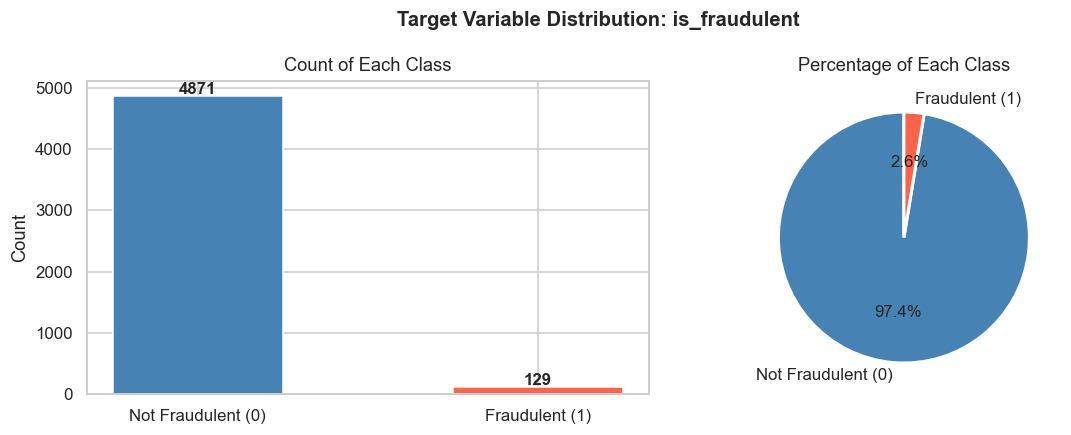

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Target Variable Distribution: is_fraudulent', fontweight='bold')

labels = ['Not Fraudulent (0)', 'Fraudulent (1)']
values = [target_counts[0], target_counts[1]]
colors = ['steelblue', 'tomato']

axes[0].bar(labels, values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[0].set_title('Count of Each Class')
axes[0].set_ylabel('Count')

axes[1].pie(values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage of Each Class')

plt.tight_layout()
plt.show()

In [14]:
numeric_cols = ['age', 'avg_order_value', 'total_orders',
                 'last_purchase', 'email_open_rate', 'loyalty_score', 'churn_risk']

print('Outlier Count per Column (IQR Method):')
outlier_summary = {}
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = count
    print(f'  {col:<20}: {count} outliers')

Outlier Count per Column (IQR Method):
  age                 : 0 outliers
  avg_order_value     : 137 outliers
  total_orders        : 42 outliers
  last_purchase       : 0 outliers
  email_open_rate     : 0 outliers
  loyalty_score       : 0 outliers
  churn_risk          : 37 outliers


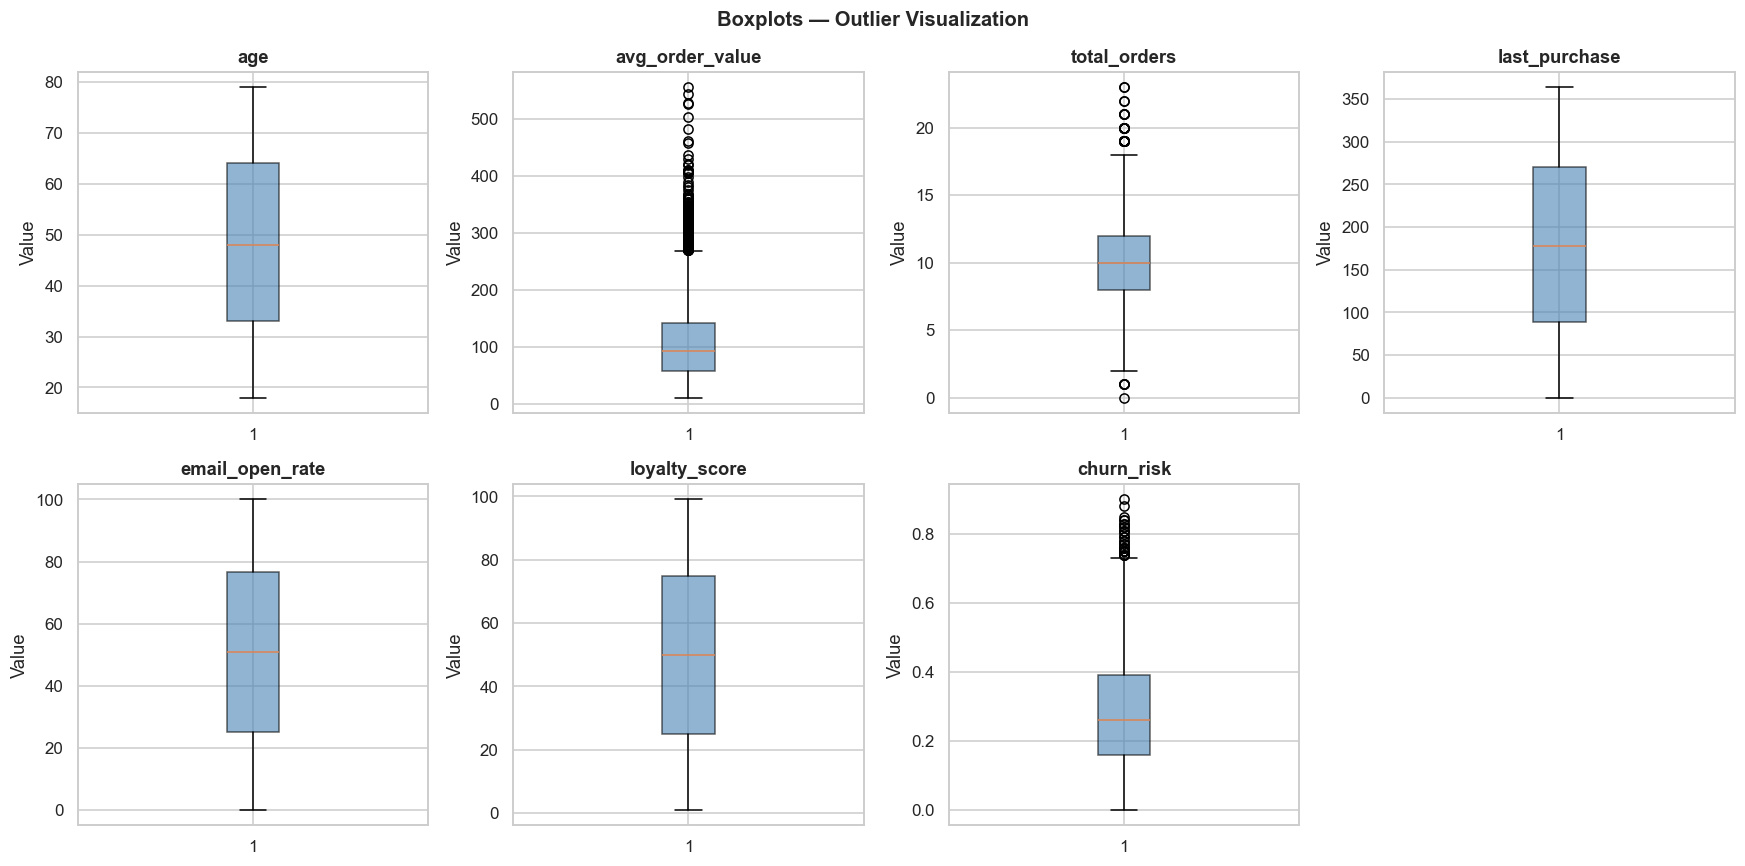

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Boxplots — Outlier Visualization', fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes_flat[i].boxplot(df[col].dropna(), patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes_flat[i].set_title(col, fontweight='bold')
    axes_flat[i].set_ylabel('Value')

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

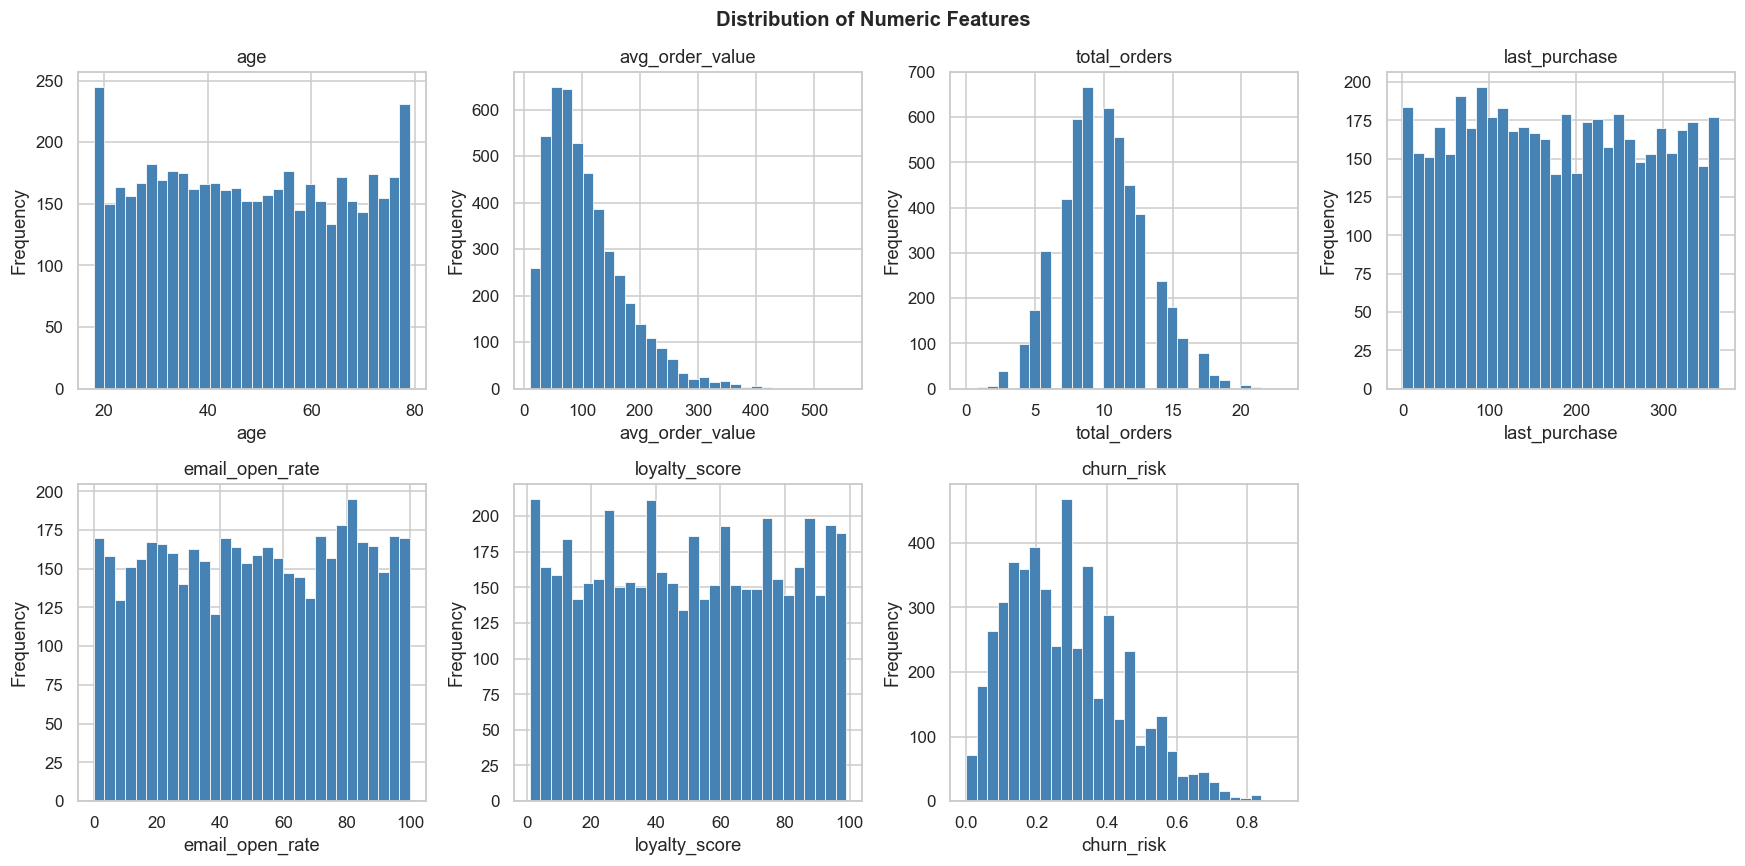

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of Numeric Features', fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes_flat[i].hist(df[col].dropna(), bins=30, color='steelblue',
                      edgecolor='white', linewidth=0.5)
    axes_flat[i].set_title(col)
    axes_flat[i].set_xlabel(col)
    axes_flat[i].set_ylabel('Frequency')

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

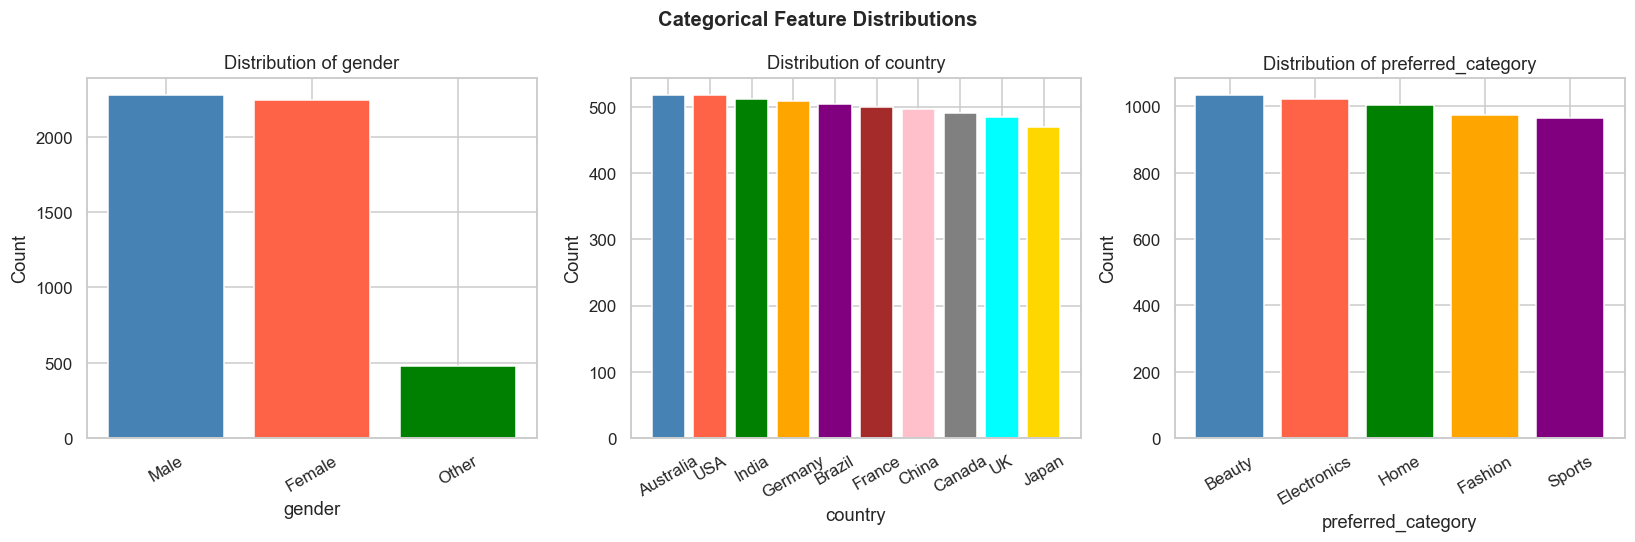

In [17]:
cat_cols = ['gender', 'country', 'preferred_category']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Categorical Feature Distributions', fontweight='bold')

colors_list = ['steelblue', 'tomato', 'green', 'orange', 'purple',
               'brown', 'pink', 'gray', 'cyan', 'gold']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=colors_list[:len(counts)], edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

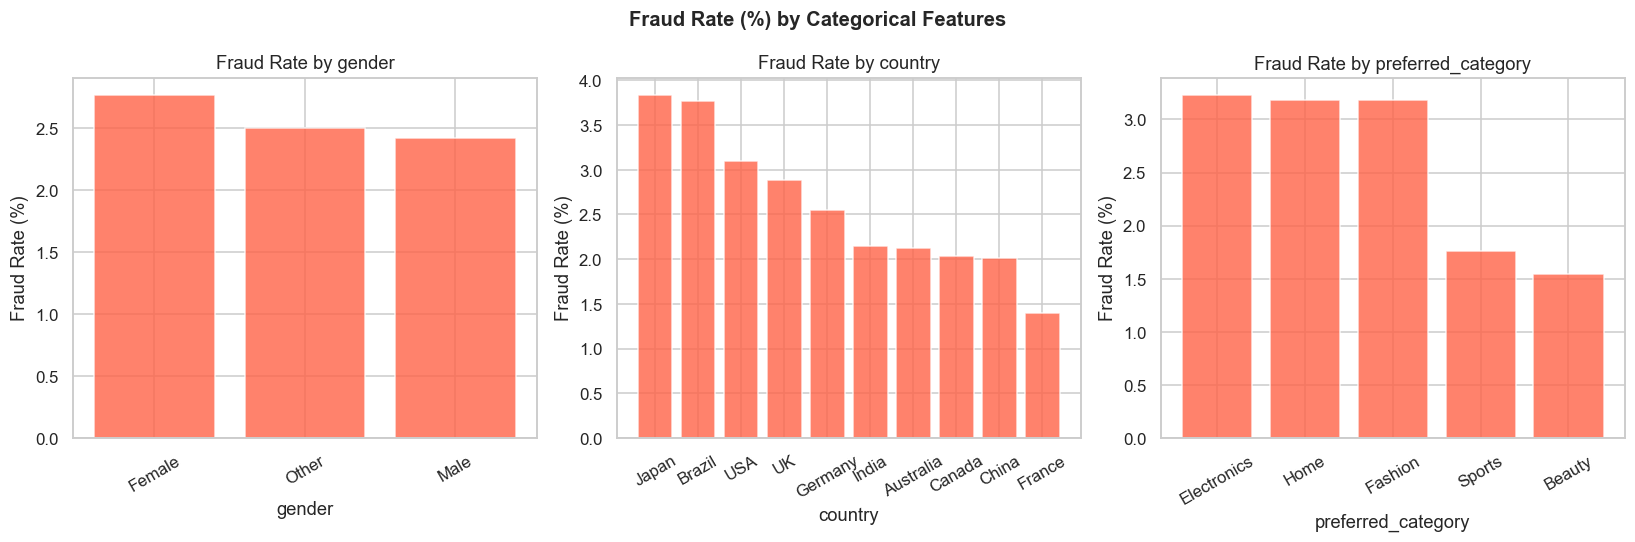

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fraud Rate (%) by Categorical Features', fontweight='bold')

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['is_fraudulent'].mean() * 100
    fraud_rate = fraud_rate.sort_values(ascending=False)
    axes[i].bar(fraud_rate.index, fraud_rate.values,
                color='tomato', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

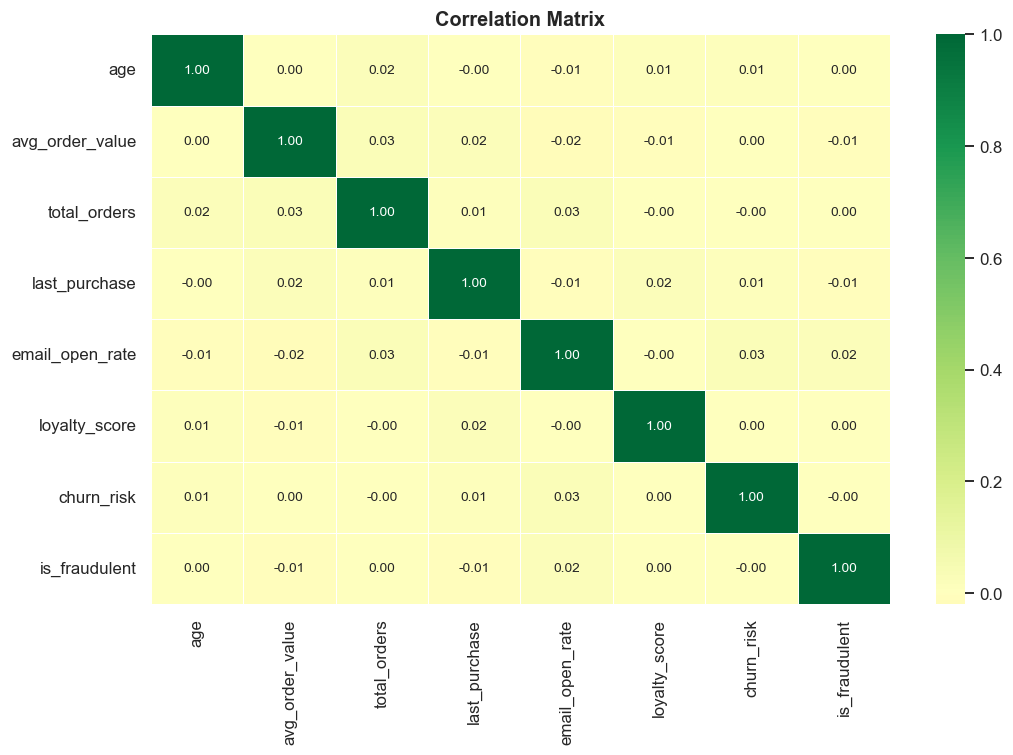

In [19]:
plt.figure(figsize=(10, 7))
corr = df[numeric_cols + ['is_fraudulent']].corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
df = df.drop(columns=['customer_id'])
print('Dropped customer_id column.')
print('New shape:', df.shape)

Dropped customer_id column.
New shape: (5000, 12)


In [22]:
print('Missing values BEFORE filling:')
print(df[['avg_order_value', 'email_open_rate']].isnull().sum().to_string())

df['avg_order_value']  = df['avg_order_value'].fillna(df['avg_order_value'].median())
df['email_open_rate']  = df['email_open_rate'].fillna(df['email_open_rate'].median())

print('\nMissing values AFTER filling:')
print(df[['avg_order_value', 'email_open_rate']].isnull().sum().to_string())


Missing values BEFORE filling:
avg_order_value    0
email_open_rate    0

Missing values AFTER filling:
avg_order_value    0
email_open_rate    0


In [23]:
cols_to_cap = ['avg_order_value', 'total_orders', 'churn_risk']

for col in cols_to_cap:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    df[col] = df[col].clip(lower=lower, upper=upper)

    print(f'{col}: {before} outliers capped between {lower:.2f} and {upper:.2f}')


avg_order_value: 169 outliers capped between -59.31 and 257.68
total_orders: 42 outliers capped between 2.00 and 18.00
churn_risk: 37 outliers capped between -0.19 and 0.74


In [24]:
df['customer_since'] = pd.to_datetime(df['customer_since'])

today = pd.Timestamp.today()

df['days_as_customer'] = (today - df['customer_since']).dt.days
df['year_joined']      = df['customer_since'].dt.year
df['month_joined']     = df['customer_since'].dt.month

df = df.drop(columns=['customer_since'])

print('New date features created:')
print('  days_as_customer, year_joined, month_joined')
print('  Original customer_since column dropped.')
print('\nDataset shape now:', df.shape)

New date features created:
  days_as_customer, year_joined, month_joined
  Original customer_since column dropped.

Dataset shape now: (5000, 14)


In [26]:
print('Categorical columns BEFORE encoding:')
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    print(f'  {col}: {df[col].unique().tolist()}')

Categorical columns BEFORE encoding:
  gender: ['Female', 'Male', 'Other']
  country: ['Brazil', 'USA', 'Australia', 'Japan', 'Canada', 'France', 'India', 'China', 'Germany', 'UK']
  preferred_category: ['Beauty', 'Electronics', 'Sports', 'Fashion', 'Home']


In [27]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
print('gender encoded:', dict(zip(le.classes_, le.transform(le.classes_))))

df = pd.get_dummies(df, columns=['country', 'preferred_category'], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('One-Hot Encoding applied to: country, preferred_category')
print('\nDataset shape after encoding:', df.shape)
print('\nAll column names now:')
print(df.columns.tolist())

gender encoded: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
One-Hot Encoding applied to: country, preferred_category

Dataset shape after encoding: (5000, 25)

All column names now:
['age', 'gender', 'avg_order_value', 'total_orders', 'last_purchase', 'is_fraudulent', 'email_open_rate', 'loyalty_score', 'churn_risk', 'days_as_customer', 'year_joined', 'month_joined', 'country_Brazil', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Japan', 'country_UK', 'country_USA', 'preferred_category_Electronics', 'preferred_category_Fashion', 'preferred_category_Home', 'preferred_category_Sports']


In [28]:
X = df.drop(columns=['is_fraudulent'])
y = df['is_fraudulent']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [31]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('Class distribution BEFORE SMOTE (training set):')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c} samples')

print('\nClass distribution AFTER SMOTE (training set):')
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c} samples')


Class distribution BEFORE SMOTE (training set):
  Class 0: 3897 samples
  Class 1: 103 samples

Class distribution AFTER SMOTE (training set):
  Class 0: 3897 samples
  Class 1: 3897 samples


In [32]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te,  y_pred) * 100
    prec = precision_score(y_te, y_pred, zero_division=0) * 100
    rec  = recall_score(y_te,    y_pred, zero_division=0) * 100
    f1   = f1_score(y_te,        y_pred, zero_division=0) * 100

    return model, y_pred, acc, prec, rec, f1

results  = []
all_preds = {}
all_models = {}


In [33]:
dt_model = DecisionTreeClassifier(
    max_depth     = 10,
    random_state  = 42,
    class_weight  = 'balanced'
)

dt_model, dt_pred, dt_acc, dt_prec, dt_rec, dt_f1 = evaluate_model(
    'Decision Tree', dt_model, X_train_sm, y_train_sm, X_test_scaled, y_test
)

all_models['Decision Tree'] = dt_model
all_preds['Decision Tree']  = dt_pred

results.append({
    'Model'    : 'Decision Tree',
    'Accuracy' : round(dt_acc,  2),
    'Precision': round(dt_prec, 2),
    'Recall'   : round(dt_rec,  2),
    'F1-Score' : round(dt_f1,   2)
})

print('Decision Tree Results:')
print(f'  Accuracy : {dt_acc:.2f}%')
print(f'  Precision: {dt_prec:.2f}%')
print(f'  Recall   : {dt_rec:.2f}%')
print(f'  F1-Score : {dt_f1:.2f}%')

Decision Tree Results:
  Accuracy : 76.70%
  Precision: 2.30%
  Recall   : 19.23%
  F1-Score : 4.12%


In [34]:
rf_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    class_weight = 'balanced'
)

rf_model, rf_pred, rf_acc, rf_prec, rf_rec, rf_f1 = evaluate_model(
    'Random Forest', rf_model, X_train_sm, y_train_sm, X_test_scaled, y_test
)

all_models['Random Forest'] = rf_model
all_preds['Random Forest']  = rf_pred

results.append({
    'Model'    : 'Random Forest',
    'Accuracy' : round(rf_acc,  2),
    'Precision': round(rf_prec, 2),
    'Recall'   : round(rf_rec,  2),
    'F1-Score' : round(rf_f1,   2)
})

print('Random Forest Results:')
print(f'  Accuracy : {rf_acc:.2f}%')
print(f'  Precision: {rf_prec:.2f}%')
print(f'  Recall   : {rf_rec:.2f}%')
print(f'  F1-Score : {rf_f1:.2f}%')

Random Forest Results:
  Accuracy : 97.30%
  Precision: 0.00%
  Recall   : 0.00%
  F1-Score : 0.00%


In [35]:
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators       = 200,
    random_state       = 42,
    eval_metric        = 'logloss',
    scale_pos_weight   = scale_weight,
    verbosity          = 0
)

xgb_model, xgb_pred, xgb_acc, xgb_prec, xgb_rec, xgb_f1 = evaluate_model(
    'XGBoost', xgb_model, X_train_sm, y_train_sm, X_test_scaled, y_test
)

all_models['XGBoost'] = xgb_model
all_preds['XGBoost']  = xgb_pred

results.append({
    'Model'    : 'XGBoost',
    'Accuracy' : round(xgb_acc,  2),
    'Precision': round(xgb_prec, 2),
    'Recall'   : round(xgb_rec,  2),
    'F1-Score' : round(xgb_f1,   2)
})

print('XGBoost Results:')
print(f'  Accuracy : {xgb_acc:.2f}%')
print(f'  Precision: {xgb_prec:.2f}%')
print(f'  Recall   : {xgb_rec:.2f}%')
print(f'  F1-Score : {xgb_f1:.2f}%')

XGBoost Results:
  Accuracy : 96.70%
  Precision: 0.00%
  Recall   : 0.00%
  F1-Score : 0.00%


In [36]:
lr_model = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42
)

lr_model, lr_pred, lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_model(
    'Logistic Regression', lr_model, X_train_sm, y_train_sm, X_test_scaled, y_test
)

all_models['Logistic Regression'] = lr_model
all_preds['Logistic Regression']  = lr_pred

results.append({
    'Model'    : 'Logistic Regression',
    'Accuracy' : round(lr_acc,  2),
    'Precision': round(lr_prec, 2),
    'Recall'   : round(lr_rec,  2),
    'F1-Score' : round(lr_f1,   2)
})

print('Logistic Regression Results:')
print(f'  Accuracy : {lr_acc:.2f}%')
print(f'  Precision: {lr_prec:.2f}%')
print(f'  Recall   : {lr_rec:.2f}%')
print(f'  F1-Score : {lr_f1:.2f}%')

Logistic Regression Results:
  Accuracy : 56.90%
  Precision: 3.45%
  Recall   : 57.69%
  F1-Score : 6.51%


In [37]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

print('='*68)
print('       MODEL PERFORMANCE COMPARISON (sorted by F1-Score)')
print('='*68)
print(results_df.to_string())
print('='*68)
print(f'\nBest Model: {results_df.iloc[0]["Model"]} (F1-Score = {results_df.iloc[0]["F1-Score"]}%)')

       MODEL PERFORMANCE COMPARISON (sorted by F1-Score)
                 Model  Accuracy  Precision  Recall  F1-Score
1  Logistic Regression      56.9       3.45   57.69      6.51
2        Decision Tree      76.7       2.30   19.23      4.12
3        Random Forest      97.3       0.00    0.00      0.00
4              XGBoost      96.7       0.00    0.00      0.00

Best Model: Logistic Regression (F1-Score = 6.51%)


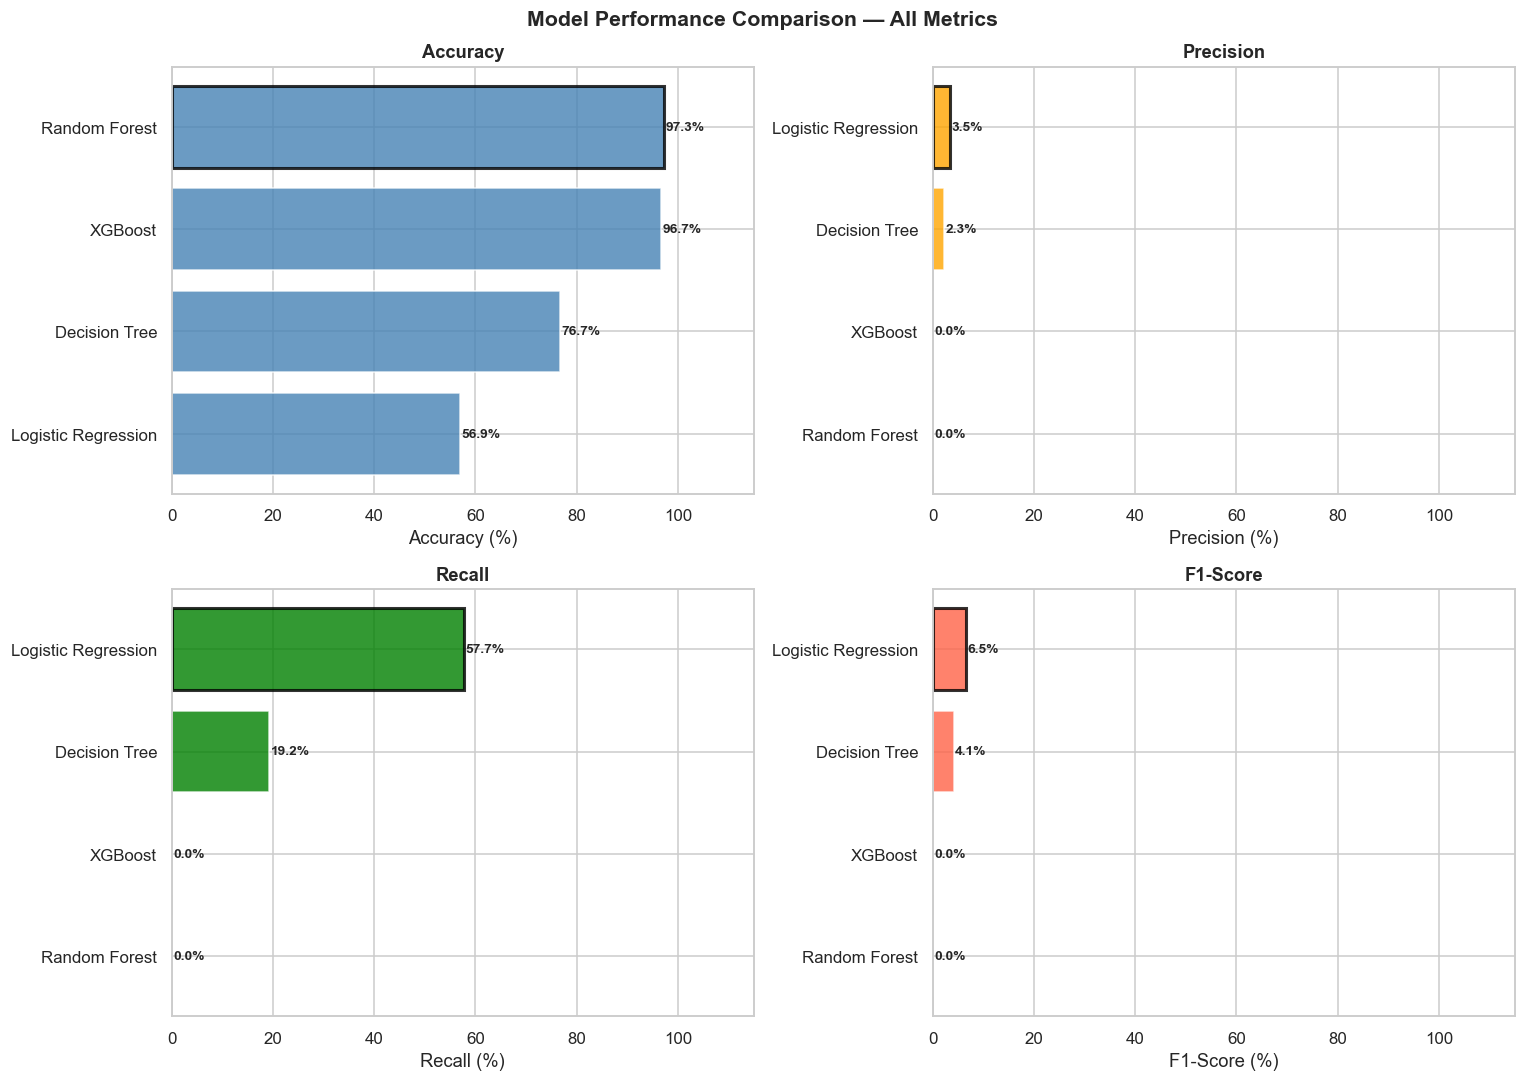

In [38]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['steelblue', 'orange', 'green', 'tomato']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=color, alpha=0.8, edgecolor='white')
    bars[-1].set_edgecolor('black')
    bars[-1].set_linewidth(2)
    for bar in bars:
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.1f}%',
                va='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_xlabel(f'{metric} (%)')
    ax.set_xlim(0, 115)

plt.tight_layout()
plt.show()

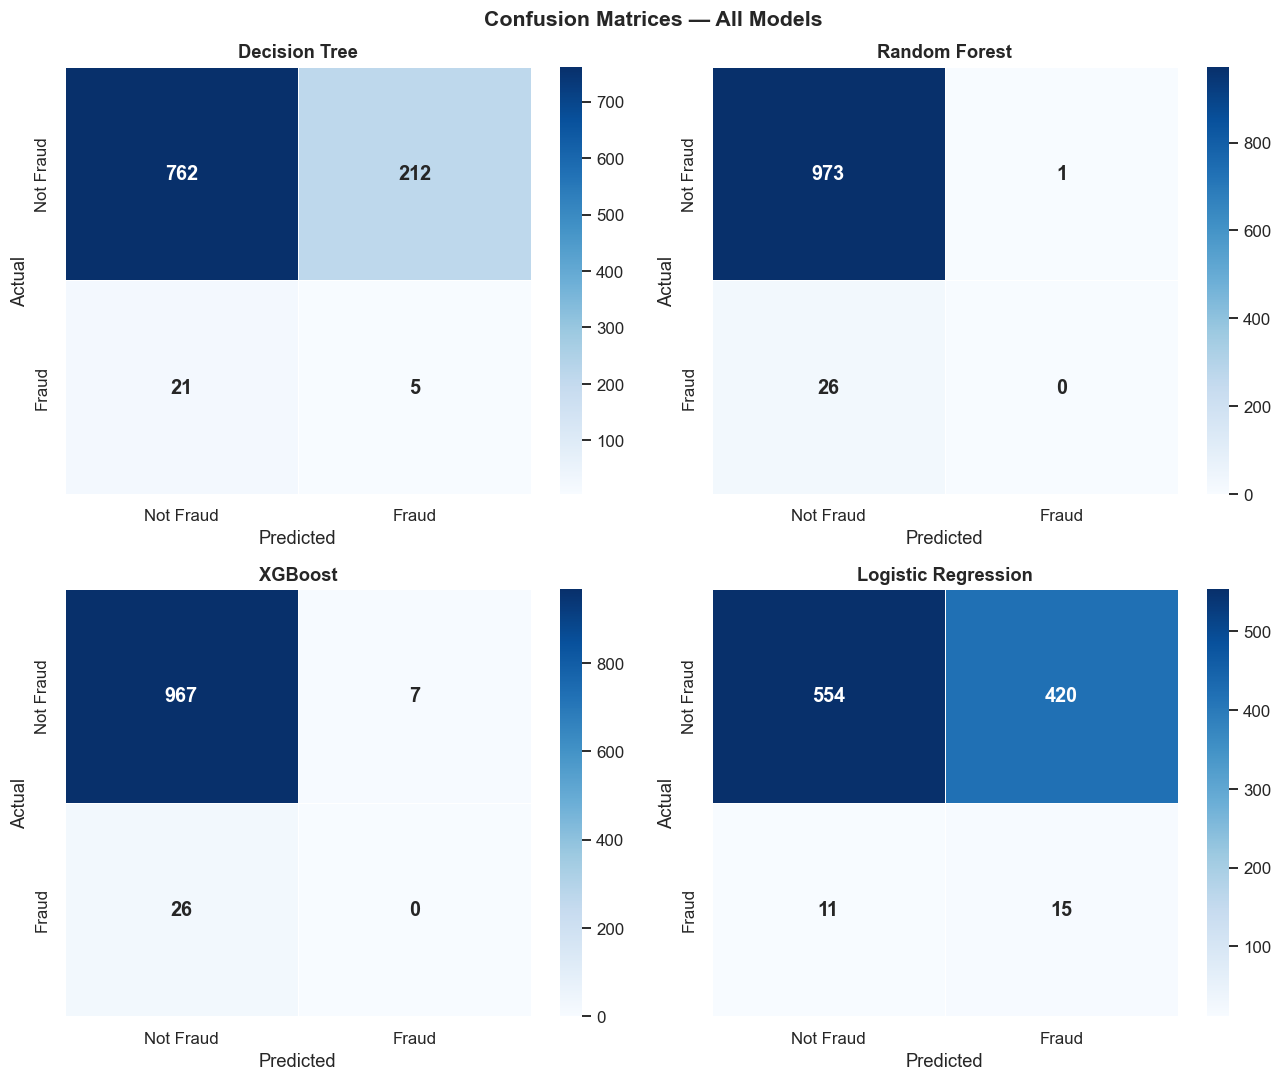

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

model_names = list(all_preds.keys())
axes_flat   = axes.flatten()

for i, name in enumerate(model_names):
    cm = confusion_matrix(y_test, all_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes_flat[i],
                annot_kws={'size': 13, 'fontweight': 'bold'},
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'])
    axes_flat[i].set_title(name, fontweight='bold')
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [40]:
for name in model_names:
    print('='*55)
    print(f'  Classification Report: {name}')
    print('='*55)
    print(classification_report(y_test, all_preds[name],
                                 target_names=['Not Fraud', 'Fraud'],
                                 zero_division=0))

  Classification Report: Decision Tree
              precision    recall  f1-score   support

   Not Fraud       0.97      0.78      0.87       974
       Fraud       0.02      0.19      0.04        26

    accuracy                           0.77      1000
   macro avg       0.50      0.49      0.45      1000
weighted avg       0.95      0.77      0.85      1000

  Classification Report: Random Forest
              precision    recall  f1-score   support

   Not Fraud       0.97      1.00      0.99       974
       Fraud       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000

  Classification Report: XGBoost
              precision    recall  f1-score   support

   Not Fraud       0.97      0.99      0.98       974
       Fraud       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg     

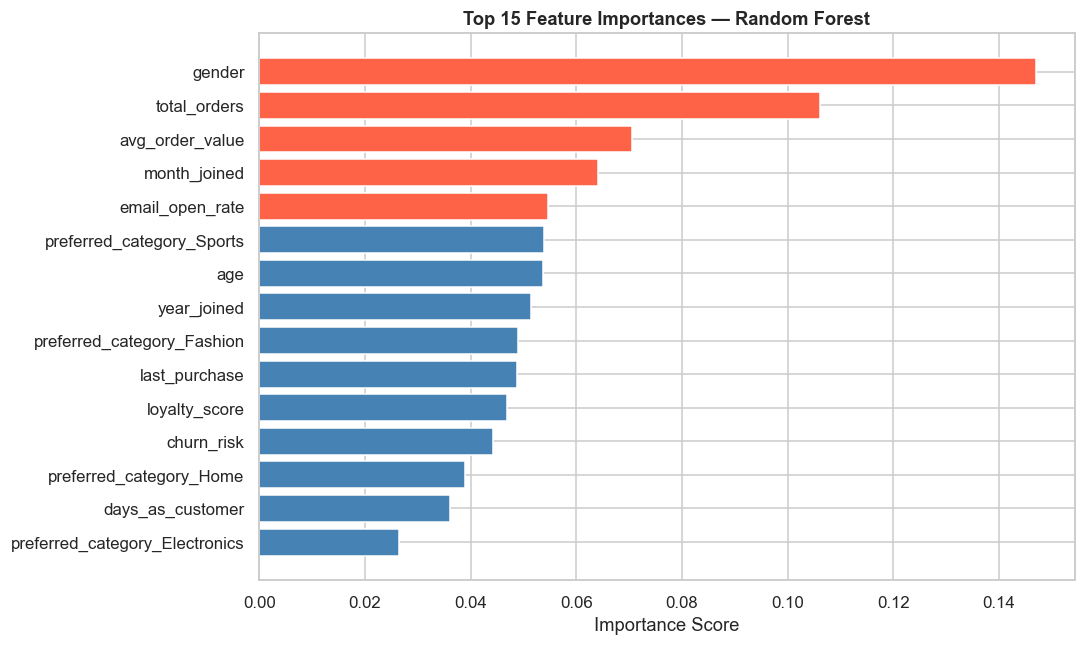

Top 5 Most Important Features:
  gender: 0.1470
  total_orders: 0.1060
  avg_order_value: 0.0705
  month_joined: 0.0641
  email_open_rate: 0.0546


In [41]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors_fi = ['tomato' if i < 5 else 'steelblue' for i in range(len(feat_imp))]
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
         color=colors_fi[::-1], edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 Most Important Features:')
for feat, imp in feat_imp.head(5).items():
    print(f'  {feat}: {imp:.4f}')

In [42]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj  = all_models[best_model_name]
best_pred       = all_preds[best_model_name]

print('BEST MODEL IDENTIFIED')
print('='*50)
print(f'Model Name : {best_model_name}')
print(f'Accuracy   : {results_df.iloc[0]["Accuracy"]}%')
print(f'Precision  : {results_df.iloc[0]["Precision"]}%')
print(f'Recall     : {results_df.iloc[0]["Recall"]}%')
print(f'F1-Score   : {results_df.iloc[0]["F1-Score"]}%')
print('='*50)

BEST MODEL IDENTIFIED
Model Name : Logistic Regression
Accuracy   : 56.9%
Precision  : 3.45%
Recall     : 57.69%
F1-Score   : 6.51%


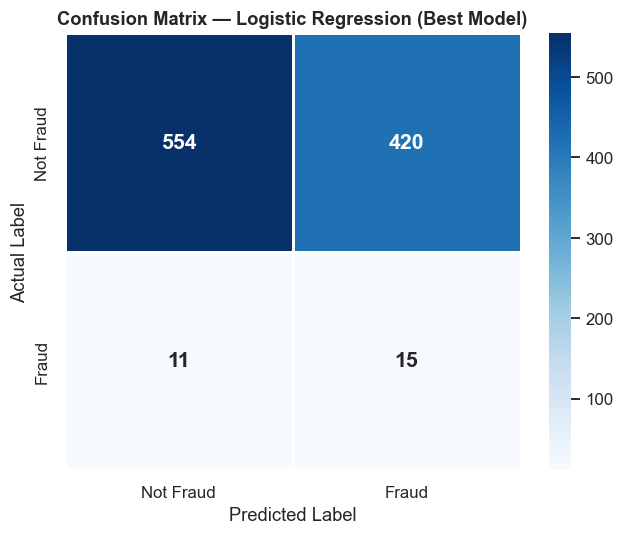

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

   Not Fraud       0.98      0.57      0.72       974
       Fraud       0.03      0.58      0.07        26

    accuracy                           0.57      1000
   macro avg       0.51      0.57      0.39      1000
weighted avg       0.96      0.57      0.70      1000



In [43]:
cm_best = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            linewidths=0.8, annot_kws={'size': 14, 'fontweight': 'bold'},
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'Confusion Matrix — {best_model_name} (Best Model)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print(f'Classification Report — {best_model_name}:')
print(classification_report(y_test, best_pred,
                             target_names=['Not Fraud', 'Fraud'],
                             zero_division=0))

In [44]:
total_test    = len(y_test)
correct_preds = (y_test.values == best_pred).sum()
wrong_preds   = total_test - correct_preds

fraud_actual    = y_test.sum()
fraud_detected  = ((y_test.values == 1) & (best_pred == 1)).sum()
fraud_missed    = fraud_actual - fraud_detected

print('Final Prediction Summary on Test Set:')
print(f'  Total test records     : {total_test}')
print(f'  Correctly predicted    : {correct_preds}')
print(f'  Wrongly predicted      : {wrong_preds}')
print(f'  Actual fraud cases     : {fraud_actual}')
print(f'  Fraud cases detected   : {fraud_detected}')
print(f'  Fraud cases missed     : {fraud_missed}')

Final Prediction Summary on Test Set:
  Total test records     : 1000
  Correctly predicted    : 569
  Wrongly predicted      : 431
  Actual fraud cases     : 26
  Fraud cases detected   : 15
  Fraud cases missed     : 11



---

### Decisions Made and Why

| Decision | Choice | Reason |
|---|---|---|
| **Missing Values** | Median Imputation | Median is robust to outliers |
| **Outliers** | IQR Capping | Keeps data, limits extreme values |
| **Date Column** | Extracted days_as_customer, year_joined, month_joined | Numeric features are more useful |
| **Encoding: gender** | Label Encoding | Only 3 categories |
| **Encoding: country, category** | One-Hot Encoding | No natural order, prevents false ranking |
| **Scaling** | StandardScaler | Standard choice; works well for all models |
| **Class Imbalance** | SMOTE | 37:1 imbalance — SMOTE generates synthetic fraud samples |
| **Evaluation Metric** | F1-Score (primary) | Best for imbalanced datasets |

---

### Model Performance Summary

| Model | Key Observation |
|---|---|
| **Decision Tree** | Simple and fast; may overfit |
| **Random Forest** | Ensemble of trees; generally strong |
| **XGBoost** | Gradient boosting; excellent for imbalanced data |
| **Logistic Regression** | Linear baseline; useful for comparison |

---
